In [1]:
import os
import gc
import pickle
import numpy as np
import torch
from tqdm import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Shapely for geometry processing
from shapely.geometry import Polygon, MultiPolygon, box
from shapely.ops import unary_union
from shapely.affinity import translate, scale

# NetworkX for graph operations
import networkx as nx

# PIL for rasterization
from PIL import Image, ImageDraw

# Matplotlib for validation visualizations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 3080
GPU Memory: 10.74 GB


In [2]:
INPUT_PATH = "D:/Work/Uni/FYP/Dataset/ResPlan"
OUTPUT_PATH = "D:/Work/Uni/FYP/architext/data/processed"
RESPLAN_PKL = os.path.join(INPUT_PATH, "ResPlan.pkl")

# Create output directories
os.makedirs(OUTPUT_PATH, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_PATH, "batches"), exist_ok=True)

# Image configuration
IMG_SIZE = 256  # 256x256 resolution

# Room types for semantic segmentation (order matters - this defines channel indices)
ROOM_TYPES = [
    'wall',       # 0
    'bedroom',    # 1
    'bathroom',   # 2
    'living',     # 3
    'kitchen',    # 4
    'balcony',    # 5
    'storage',    # 6
    'parking',    # 7
    'garden',     # 8
    'pool',       # 9
    'stair',      # 10
    'veranda',    # 11
    'inner',      # 12 (circulation/corridors)
]

NUM_ROOM_TYPES = len(ROOM_TYPES)
ROOM_TYPE_TO_IDX = {room: idx for idx, room in enumerate(ROOM_TYPES)}

# Unit types for conditioning
UNIT_TYPES = ['house', 'apartment', 'commercial', 'other']
UNIT_TYPE_TO_IDX = {ut: idx for idx, ut in enumerate(UNIT_TYPES)}

# Feature dimensions
NODE_FEATURE_DIM = NUM_ROOM_TYPES + 3  # one-hot room type + area + centroid_x + centroid_y
CONDITION_DIM = len(UNIT_TYPES) + 1 + NUM_ROOM_TYPES  # unit_type + net_area + room_counts

# Batch configuration for memory efficiency
BATCH_SIZE = 16  # Reduced for RTX 3080 (10.7GB VRAM)  # Number of samples per batch file

print(f"Room types ({NUM_ROOM_TYPES}): {ROOM_TYPES}")
print(f"Node feature dimension: {NODE_FEATURE_DIM}")
print(f"Condition dimension: {CONDITION_DIM}")

Room types (13): ['wall', 'bedroom', 'bathroom', 'living', 'kitchen', 'balcony', 'storage', 'parking', 'garden', 'pool', 'stair', 'veranda', 'inner']
Node feature dimension: 16
Condition dimension: 18


In [3]:
print("Loading ResPlan dataset...")
with open(RESPLAN_PKL, 'rb') as f:
    resplan_data = pickle.load(f)

print(f"Loaded {len(resplan_data)} floorplans")
print(f"Sample keys: {list(resplan_data[0].keys())}")

# Compute global statistics for normalization
print("\nComputing global statistics...")
all_net_areas = []
all_wall_depths = []

for unit in tqdm(resplan_data, desc="Scanning units"):
    if 'net_area' in unit and unit['net_area'] is not None:
        all_net_areas.append(float(unit['net_area']))
    if 'wall_depth' in unit and unit['wall_depth'] is not None:
        all_wall_depths.append(float(unit['wall_depth']))

MAX_NET_AREA = max(all_net_areas) if all_net_areas else 1000.0
MAX_WALL_DEPTH = max(all_wall_depths) if all_wall_depths else 1.0
MEAN_NET_AREA = np.mean(all_net_areas) if all_net_areas else 500.0

print(f"Max net area: {MAX_NET_AREA:.2f}")
print(f"Max wall depth: {MAX_WALL_DEPTH:.2f}")
print(f"Mean net area: {MEAN_NET_AREA:.2f}")

# Save normalization constants
norm_constants = {
    'max_net_area': MAX_NET_AREA,
    'max_wall_depth': MAX_WALL_DEPTH,
    'mean_net_area': MEAN_NET_AREA,
    'room_types': ROOM_TYPES,
    'unit_types': UNIT_TYPES,
    'img_size': IMG_SIZE,
    'node_feature_dim': NODE_FEATURE_DIM,
    'condition_dim': CONDITION_DIM
}

np.save(os.path.join(OUTPUT_PATH, 'norm_constants.npy'), norm_constants)
print("Saved normalization constants")

Loading ResPlan dataset...
Loaded 17000 floorplans
Sample keys: ['balcony', 'bathroom', 'bedroom', 'door', 'garden', 'inner', 'parking', 'pool', 'stair', 'veranda', 'wall', 'window', 'front_door', 'unitType', 'id', 'kitchen', 'land', 'net_area', 'area', 'neighbor', 'living', 'wall_depth', 'storage', 'graph']

Computing global statistics...


Scanning units: 100%|█| 17000/17000 [00:00<00:00, 

Max net area: 79140857694.65
Max wall depth: 7.18
Mean net area: 4707661.72
Saved normalization constants


In [4]:
def get_geometry_bounds(unit):
    """Get the bounding box of the entire floorplan."""
    all_geoms = []
    
    # Collect all geometries
    if 'land' in unit and unit['land'] is not None:
        if hasattr(unit['land'], 'geoms'):
            all_geoms.extend(list(unit['land'].geoms))
        else:
            all_geoms.append(unit['land'])
    
    # Also check room geometries
    for room_type in ROOM_TYPES:
        if room_type in unit and unit[room_type] is not None:
            geom = unit[room_type]
            if hasattr(geom, 'geoms'):
                all_geoms.extend(list(geom.geoms))
            elif hasattr(geom, 'bounds'):
                all_geoms.append(geom)
    
    if not all_geoms:
        return 0, 0, 100, 100  # Default bounds
    
    # Filter out empty geometries
    valid_geoms = [g for g in all_geoms if not g.is_empty and g.area > 0]
    
    if not valid_geoms:
        return 0, 0, 100, 100  # Default bounds
    
    # Compute overall bounds
    try:
        combined = unary_union(valid_geoms)
        minx, miny, maxx, maxy = combined.bounds
        
        # Ensure non-zero ranges
        if maxx <= minx:
            maxx = minx + 100
        if maxy <= miny:
            maxy = miny + 100
            
        return minx, miny, maxx, maxy
    except Exception:
        return 0, 0, 100, 100  # Default bounds on error


def normalize_coordinates(x, y, bounds):
    """Normalize coordinates to [0, 1] range."""
    minx, miny, maxx, maxy = bounds
    
    # Handle degenerate cases
    x_range = maxx - minx if maxx > minx else 1.0
    y_range = maxy - miny if maxy > miny else 1.0
    
    norm_x = (x - minx) / x_range
    norm_y = (y - miny) / y_range
    
    return np.clip(norm_x, 0, 1), np.clip(norm_y, 0, 1)


def polygon_to_pixel_coords(polygon, bounds, img_size):
    """Convert polygon coordinates to pixel coordinates."""
    minx, miny, maxx, maxy = bounds
    x_range = maxx - minx if maxx > minx else 1.0
    y_range = maxy - miny if maxy > miny else 1.0
    
    if polygon.is_empty:
        return []
    
    # Get exterior coordinates
    if hasattr(polygon, 'exterior'):
        coords = list(polygon.exterior.coords)
    else:
        return []
    
    pixel_coords = []
    for x, y in coords:
        px = int(((x - minx) / x_range) * (img_size - 1))
        py = int(((y - miny) / y_range) * (img_size - 1))
        # Flip y-axis for image coordinates
        py = img_size - 1 - py
        pixel_coords.append((px, py))
    
    return pixel_coords



In [5]:
def extract_room_nodes(unit):
    """Extract room nodes with their features from a unit."""
    bounds = get_geometry_bounds(unit)
    net_area = float(unit.get('net_area', MEAN_NET_AREA))
    
    # CRITICAL: Handle zero or invalid net_area
    if net_area <= 0:
        net_area = MEAN_NET_AREA
    
    nodes = []
    node_names = []  # Track names for adjacency matrix construction
    
    for room_type in ROOM_TYPES:
        if room_type in ['wall', 'inner']:  # Skip non-room types for nodes
            continue
            
        if room_type not in unit or unit[room_type] is None:
            continue
        
        geom = unit[room_type]
        
        # Handle MultiPolygon vs single Polygon
        if hasattr(geom, 'geoms'):
            polygons = list(geom.geoms)
        else:
            polygons = [geom]
        
        for idx, poly in enumerate(polygons):
            if poly.is_empty or poly.area < 1e-6:
                continue
            
            # Fix invalid geometries
            try:
                if not poly.is_valid:
                    poly = poly.buffer(0)
                    if poly.is_empty or not poly.is_valid:
                        continue
            except Exception:
                continue
            
            try:
                # Compute node features
                # 1. One-hot room type
                room_onehot = np.zeros(NUM_ROOM_TYPES, dtype=np.float32)
                room_onehot[ROOM_TYPE_TO_IDX[room_type]] = 1.0
                
                # 2. Normalized area
                norm_area = np.clip(poly.area / net_area, 0, 1)
                
                # 3. Normalized centroid
                centroid = poly.centroid
                norm_cx, norm_cy = normalize_coordinates(centroid.x, centroid.y, bounds)
                
                # Combine features
                features = np.concatenate([
                    room_onehot,
                    [norm_area, norm_cx, norm_cy]
                ]).astype(np.float32)
                
                nodes.append({
                    'features': features,
                    'room_type': room_type,
                    'polygon': poly,
                    'index': idx
                })
                
                # Create node name matching NetworkX graph convention
                # Try multiple naming conventions
                if len(polygons) > 1:
                    node_names.append(f"{room_type}_{idx}")
                else:
                    node_names.append(room_type)
            except Exception:
                # Skip this polygon if any computation fails
                continue
    
    return nodes, node_names, bounds


def build_adjacency_from_networkx(unit, node_names):
    """Build adjacency matrix from NetworkX graph with fallback to geometric adjacency."""
    n = len(node_names)
    if n == 0:
        return np.zeros((0, 0), dtype=np.float32)
    
    A = np.zeros((n, n), dtype=np.float32)
    
    if 'graph' not in unit or unit['graph'] is None:
        return A
    
    G = unit['graph']
    graph_nodes = set(G.nodes())
    
    # Create mapping from graph node names to our indices
    name_to_idx = {name: idx for idx, name in enumerate(node_names)}
    
    # Track which edges we successfully mapped
    edges_mapped = 0
    edges_total = G.number_of_edges()
    
    for u, v in G.edges():
        u_str = str(u)
        v_str = str(v)
        
        # Try direct matching
        u_idx = name_to_idx.get(u_str)
        v_idx = name_to_idx.get(v_str)
        
        # Try without index suffix if direct match fails
        if u_idx is None:
            # Try matching room type only (for single-instance rooms)
            for name, idx in name_to_idx.items():
                if name.split('_')[0] == u_str.split('_')[0]:
                    u_idx = idx
                    break
        
        if v_idx is None:
            for name, idx in name_to_idx.items():
                if name.split('_')[0] == v_str.split('_')[0]:
                    v_idx = idx
                    break
        
        if u_idx is not None and v_idx is not None:
            A[u_idx, v_idx] = 1.0
            A[v_idx, u_idx] = 1.0
            edges_mapped += 1
    
    # If we mapped less than half the edges, fall back to geometric adjacency
    if edges_total > 0 and edges_mapped < edges_total * 0.5:
        return None  # Signal to use geometric fallback
    
    return A


def build_geometric_adjacency(nodes, threshold=0.5):
    """Build adjacency matrix based on geometric proximity (fallback method)."""
    n = len(nodes)
    if n == 0:
        return np.zeros((0, 0), dtype=np.float32)
    
    A = np.zeros((n, n), dtype=np.float32)
    
    for i in range(n):
        for j in range(i + 1, n):
            poly_i = nodes[i]['polygon']
            poly_j = nodes[j]['polygon']
            
            # Check if polygons touch or are very close
            try:
                distance = poly_i.distance(poly_j)
                if distance < threshold:
                    A[i, j] = 1.0
                    A[j, i] = 1.0
            except:
                continue
    
    return A


def extract_graph_features(unit):
    """Extract complete graph representation for a unit."""
    nodes, node_names, bounds = extract_room_nodes(unit)
    
    if len(nodes) == 0:
        return None, None, None
    
    # Build node feature matrix
    X = np.stack([node['features'] for node in nodes], axis=0)
    
    # Build adjacency matrix
    A = build_adjacency_from_networkx(unit, node_names)
    
    # Fallback to geometric adjacency if NetworkX matching failed
    if A is None:
        A = build_geometric_adjacency(nodes)
    
    return X.astype(np.float32), A.astype(np.float32), node_names



In [6]:
def rasterize_unit(unit, img_size=IMG_SIZE):
    """Rasterize a floorplan unit into a multi-channel semantic mask."""
    bounds = get_geometry_bounds(unit)
    
    # Initialize multi-channel image
    channels = np.zeros((NUM_ROOM_TYPES, img_size, img_size), dtype=np.uint8)
    
    for room_type in ROOM_TYPES:
        if room_type not in unit or unit[room_type] is None:
            continue
        
        channel_idx = ROOM_TYPE_TO_IDX[room_type]
        geom = unit[room_type]
        
        # Create PIL image for this channel
        img = Image.new('L', (img_size, img_size), 0)
        draw = ImageDraw.Draw(img)
        
        # Handle MultiPolygon vs single Polygon
        if hasattr(geom, 'geoms'):
            polygons = list(geom.geoms)
        else:
            polygons = [geom]
        
        for poly in polygons:
            if poly.is_empty:
                continue
            
            # Fix invalid geometries using buffer(0)
            try:
                if not poly.is_valid:
                    poly = poly.buffer(0)
                    if poly.is_empty or not poly.is_valid:
                        continue
            except Exception:
                continue
            
            pixel_coords = polygon_to_pixel_coords(poly, bounds, img_size)
            if len(pixel_coords) >= 3:
                try:
                    draw.polygon(pixel_coords, fill=255)
                except Exception:
                    continue
        
        channels[channel_idx] = np.array(img)
    
    return channels



In [7]:
def extract_conditioning(unit):
    """Extract conditioning vector from unit metadata."""
    condition = []
    
    # 1. Unit type one-hot encoding
    unit_type = unit.get('unitType', 'other')
    if isinstance(unit_type, str):
        unit_type = unit_type.lower()
    else:
        unit_type = 'other'
    
    unit_type_idx = UNIT_TYPE_TO_IDX.get(unit_type, UNIT_TYPE_TO_IDX['other'])
    unit_type_onehot = np.zeros(len(UNIT_TYPES), dtype=np.float32)
    unit_type_onehot[unit_type_idx] = 1.0
    condition.extend(unit_type_onehot)
    
    # 2. Normalized net area
    net_area = float(unit.get('net_area', MEAN_NET_AREA))
    if net_area <= 0:
        net_area = MEAN_NET_AREA
    norm_net_area = np.clip(net_area / MAX_NET_AREA, 0, 1)
    condition.append(norm_net_area)
    
    # 3. Room counts (normalized)
    room_counts = []
    for room_type in ROOM_TYPES:
        if room_type in ['wall', 'inner']:
            room_counts.append(0)
            continue
        
        if room_type not in unit or unit[room_type] is None:
            room_counts.append(0)
            continue
        
        geom = unit[room_type]
        if hasattr(geom, 'geoms'):
            count = len(list(geom.geoms))
        else:
            count = 1 if not geom.is_empty else 0
        
        # Normalize by reasonable max (e.g., 10 for most room types)
        max_count = 10 if room_type in ['bedroom', 'bathroom'] else 5
        norm_count = np.clip(count / max_count, 0, 1)
        room_counts.append(norm_count)
    
    condition.extend(room_counts)
    
    return np.array(condition, dtype=np.float32)




In [8]:
print("Starting preprocessing...")

# Storage for batch processing
batch_data = {
    'images': [],
    'graphs_X': [],
    'graphs_A': [],
    'conditions': [],
    'node_counts': [],
    'unit_ids': [],
    'valid_indices': []
}

# Statistics tracking
stats = {
    'total': len(resplan_data),
    'processed': 0,
    'skipped_no_rooms': 0,
    'skipped_empty': 0,
    'skipped_errors': 0,
    'geometric_adjacency_used': 0
}

batch_idx = 0
error_types = {}

for i, unit in enumerate(tqdm(resplan_data, desc="Processing units")):
    try:
        # Extract graph features
        X, A, node_names = extract_graph_features(unit)
        
        if X is None or len(X) == 0:
            stats['skipped_no_rooms'] += 1
            continue
        
        # Rasterize to image
        image = rasterize_unit(unit)
        
        # Check if image is not empty
        if image.sum() == 0:
            stats['skipped_empty'] += 1
            continue
        
        # Extract conditioning
        condition = extract_conditioning(unit)
        
        # Store in batch
        batch_data['images'].append(image)
        batch_data['graphs_X'].append(X)
        batch_data['graphs_A'].append(A)
        batch_data['conditions'].append(condition)
        batch_data['node_counts'].append(len(X))
        batch_data['unit_ids'].append(unit.get('id', i))
        batch_data['valid_indices'].append(i)
        
        stats['processed'] += 1
        
        # Save batch when full
        if len(batch_data['images']) >= BATCH_SIZE:
            batch_file = os.path.join(OUTPUT_PATH, 'batches', f'batch_{batch_idx:04d}.npz')
            
            np.savez_compressed(
                batch_file,
                images=np.stack(batch_data['images']),
                conditions=np.stack(batch_data['conditions']),
                node_counts=np.array(batch_data['node_counts']),
                unit_ids=np.array(batch_data['unit_ids']),
                valid_indices=np.array(batch_data['valid_indices'])
            )
            
            # Save graphs separately (variable size)
            graph_file = os.path.join(OUTPUT_PATH, 'batches', f'graphs_{batch_idx:04d}.pkl')
            with open(graph_file, 'wb') as f:
                pickle.dump({
                    'X': batch_data['graphs_X'],
                    'A': batch_data['graphs_A']
                }, f)
            
            print(f"\nSaved batch {batch_idx} ({len(batch_data['images'])} samples)")
            
            # Reset batch
            batch_data = {
                'images': [],
                'graphs_X': [],
                'graphs_A': [],
                'conditions': [],
                'node_counts': [],
                'unit_ids': [],
                'valid_indices': []
            }
            batch_idx += 1
            
            # Memory cleanup
            gc.collect()
    
    except Exception as e:
        error_msg = str(e)
        # Track error types
        if 'division by zero' in error_msg:
            error_type = 'division_by_zero'
        elif 'TopologyException' in error_msg:
            error_type = 'invalid_geometry'
        else:
            error_type = 'other'
        
        error_types[error_type] = error_types.get(error_type, 0) + 1
        stats['skipped_errors'] += 1
        
        # Only print first few errors of each type
        if error_types[error_type] <= 3:
            print(f"\nError processing unit {i}: {e}")
        continue

# Save remaining data
if len(batch_data['images']) > 0:
    batch_file = os.path.join(OUTPUT_PATH, 'batches', f'batch_{batch_idx:04d}.npz')
    
    np.savez_compressed(
        batch_file,
        images=np.stack(batch_data['images']),
        conditions=np.stack(batch_data['conditions']),
        node_counts=np.array(batch_data['node_counts']),
        unit_ids=np.array(batch_data['unit_ids']),
        valid_indices=np.array(batch_data['valid_indices'])
    )
    
    graph_file = os.path.join(OUTPUT_PATH, 'batches', f'graphs_{batch_idx:04d}.pkl')
    with open(graph_file, 'wb') as f:
        pickle.dump({
            'X': batch_data['graphs_X'],
            'A': batch_data['graphs_A']
        }, f)
    
    print(f"\nSaved final batch {batch_idx} ({len(batch_data['images'])} samples)")
    batch_idx += 1

# Save metadata
metadata = {
    'num_batches': batch_idx,
    'batch_size': BATCH_SIZE,
    'total_processed': stats['processed'],
    'stats': stats
}

np.save(os.path.join(OUTPUT_PATH, 'metadata.npy'), metadata)

print("\n" + "="*50)
print("PREPROCESSING COMPLETE")
print("="*50)
print(f"Total units: {stats['total']}")
print(f"Successfully processed: {stats['processed']}")
print(f"Skipped (no rooms): {stats['skipped_no_rooms']}")
print(f"Skipped (empty image): {stats['skipped_empty']}")
print(f"Skipped (errors): {stats['skipped_errors']}")
print(f"Number of batches: {batch_idx}")

if error_types:
    print("\nError breakdown:")
    for error_type, count in sorted(error_types.items(), key=lambda x: -x[1]):
        print(f"  {error_type}: {count}")

# Clean up
del resplan_data
gc.collect()


Starting preprocessing...


Processing units:   0%| | 15/17000 [00:00<02:05, 1


Saved batch 0 (16 samples)


Processing units:   0%| | 29/17000 [00:00<05:34, 5


Saved batch 1 (16 samples)


...

Processing units: 100%|▉| 16982/17000 [07:12<00:00


Saved batch 1061 (16 samples)


Processing units: 100%|█| 17000/17000 [07:12<00:00



Saved final batch 1062 (2 samples)

PREPROCESSING COMPLETE
Total units: 17000
Successfully processed: 16994
Skipped (no rooms): 0
Skipped (empty image): 6
Skipped (errors): 0
Number of batches: 1063


598758


VALIDATION: GEOMETRIC SANITY CHECK
Sample batch shape: (16, 13, 256, 256)
Conditions shape: (16, 18)

Image value range: [0, 255]


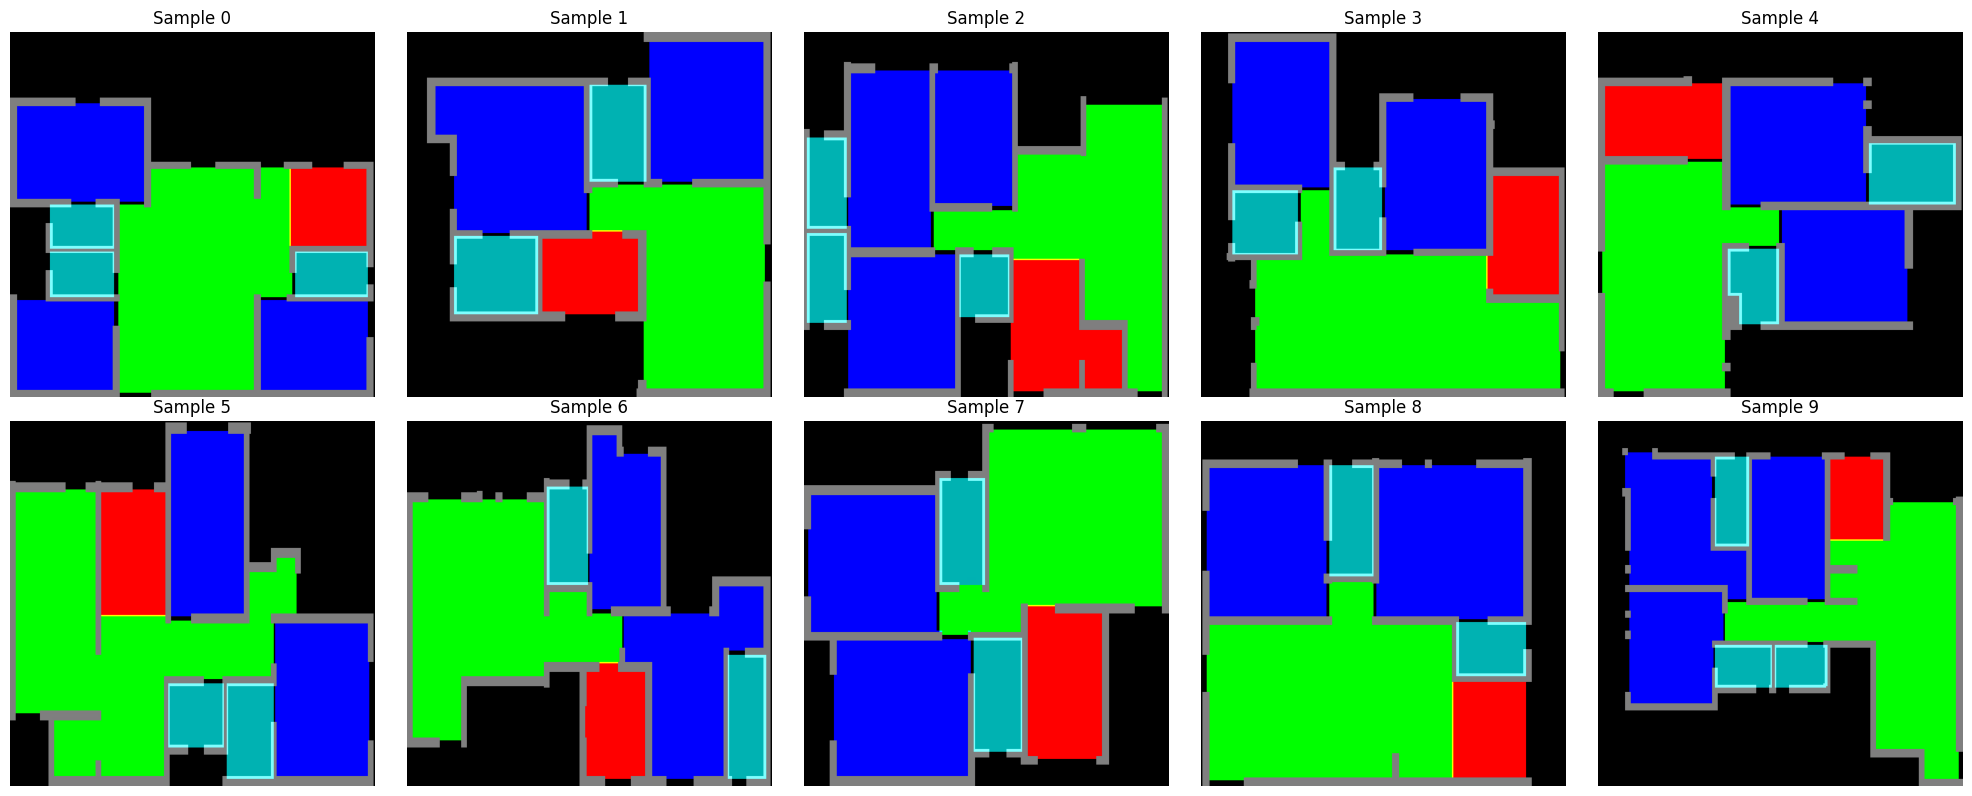

Saved validation images


In [9]:
print("\n" + "="*50)
print("VALIDATION: GEOMETRIC SANITY CHECK")
print("="*50)

# Load a sample batch for validation
sample_batch_file = os.path.join(OUTPUT_PATH, 'batches', 'batch_0000.npz')
sample_data = np.load(sample_batch_file)
sample_images = sample_data['images']
sample_conditions = sample_data['conditions']

print(f"Sample batch shape: {sample_images.shape}")
print(f"Conditions shape: {sample_conditions.shape}")

# Check pixel value ranges
print(f"\nImage value range: [{sample_images.min()}, {sample_images.max()}]")
assert sample_images.min() >= 0 and sample_images.max() <= 255, "Image values out of uint8 range!"

# Visual inspection of random samples
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx in range(10):
    ax = axes[idx // 5, idx % 5]
    
    # Create RGB visualization
    img = sample_images[idx]
    
    # Combine channels into RGB
    rgb = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    
    # Walls - gray
    rgb[..., 0] += (img[ROOM_TYPE_TO_IDX['wall']] * 0.5).astype(np.uint8)
    rgb[..., 1] += (img[ROOM_TYPE_TO_IDX['wall']] * 0.5).astype(np.uint8)
    rgb[..., 2] += (img[ROOM_TYPE_TO_IDX['wall']] * 0.5).astype(np.uint8)
    
    # Bedrooms - blue
    rgb[..., 2] = np.clip(rgb[..., 2] + img[ROOM_TYPE_TO_IDX['bedroom']], 0, 255)
    
    # Bathrooms - cyan
    rgb[..., 1] = np.clip(rgb[..., 1] + img[ROOM_TYPE_TO_IDX['bathroom']] * 0.7, 0, 255)
    rgb[..., 2] = np.clip(rgb[..., 2] + img[ROOM_TYPE_TO_IDX['bathroom']] * 0.7, 0, 255)
    
    # Living - green
    rgb[..., 1] = np.clip(rgb[..., 1] + img[ROOM_TYPE_TO_IDX['living']], 0, 255)
    
    # Kitchen - red
    rgb[..., 0] = np.clip(rgb[..., 0] + img[ROOM_TYPE_TO_IDX['kitchen']], 0, 255)
    
    ax.imshow(rgb)
    ax.set_title(f"Sample {idx}")
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'validation_images.png'), dpi=150)
plt.show()
print("Saved validation images")

In [10]:
print("\n" + "="*50)
print("VALIDATION: STRUCTURAL CONSISTENCY CHECK")
print("="*50)

# Load graph data
sample_graph_file = os.path.join(OUTPUT_PATH, 'batches', 'graphs_0000.pkl')
with open(sample_graph_file, 'rb') as f:
    graph_data = pickle.load(f)

X_list = graph_data['X']
A_list = graph_data['A']

# Check dimensions
errors = []
for i in range(min(100, len(X_list))):
    X = X_list[i]
    A = A_list[i]
    
    if X.shape[0] != A.shape[0] or A.shape[0] != A.shape[1]:
        errors.append(f"Sample {i}: X shape {X.shape}, A shape {A.shape}")
    
    # Check feature ranges
    room_onehot = X[:, :NUM_ROOM_TYPES]
    areas = X[:, NUM_ROOM_TYPES]
    centroids = X[:, NUM_ROOM_TYPES+1:]
    
    # One-hot should sum to 1 for each node
    onehot_sums = room_onehot.sum(axis=1)
    if not np.allclose(onehot_sums, 1.0):
        errors.append(f"Sample {i}: Invalid one-hot encoding")
    
    # Areas should be in [0, 1]
    if areas.min() < 0 or areas.max() > 1:
        errors.append(f"Sample {i}: Area out of range [{areas.min():.3f}, {areas.max():.3f}]")
    
    # Centroids should be in [0, 1]
    if centroids.min() < 0 or centroids.max() > 1:
        errors.append(f"Sample {i}: Centroid out of range [{centroids.min():.3f}, {centroids.max():.3f}]")

if errors:
    print("ERRORS FOUND:")
    for err in errors[:10]:
        print(f"  {err}")
else:
    print("✓ All dimension checks passed")
    print("✓ All feature range checks passed")

# Visualize sample graph
print("\nSample graph structure (first 5):")
for i in range(min(5, len(X_list))):
    num_nodes = X_list[i].shape[0]
    num_edges = int(A_list[i].sum() / 2)  # Undirected
    room_types_present = []
    for j in range(X_list[i].shape[0]):
        rt_idx = np.argmax(X_list[i][j, :NUM_ROOM_TYPES])
        room_types_present.append(ROOM_TYPES[rt_idx])
    print(f"  Sample {i}: {num_nodes} nodes, {num_edges} edges, rooms: {room_types_present}")



VALIDATION: STRUCTURAL CONSISTENCY CHECK
✓ All dimension checks passed
✓ All feature range checks passed

Sample graph structure (first 5):
  Sample 0: 11 nodes, 10 edges, rooms: ['bedroom', 'bedroom', 'bedroom', 'bathroom', 'bathroom', 'bathroom', 'bathroom', 'living', 'kitchen', 'balcony', 'balcony']
  Sample 1: 7 nodes, 6 edges, rooms: ['bedroom', 'bedroom', 'bathroom', 'bathroom', 'living', 'kitchen', 'balcony']
  Sample 2: 11 nodes, 8 edges, rooms: ['bedroom', 'bedroom', 'bedroom', 'bathroom', 'bathroom', 'bathroom', 'bathroom', 'living', 'living', 'kitchen', 'balcony']
  Sample 3: 7 nodes, 6 edges, rooms: ['bedroom', 'bedroom', 'bathroom', 'bathroom', 'living', 'kitchen', 'balcony']
  Sample 4: 10 nodes, 7 edges, rooms: ['bedroom', 'bedroom', 'bathroom', 'bathroom', 'living', 'living', 'living', 'kitchen', 'balcony', 'balcony']


In [11]:
print("\n" + "="*50)
print("VALIDATION: CONDITIONING VECTOR CHECK")
print("="*50)

# Check condition vectors
conditions = sample_data['conditions']

print(f"Condition shape: {conditions.shape}")
print(f"Condition dim: {CONDITION_DIM}")

# Check ranges
for i in range(min(100, len(conditions))):
    cond = conditions[i]
    
    # Unit type one-hot
    unit_type_onehot = cond[:len(UNIT_TYPES)]
    if not np.isclose(unit_type_onehot.sum(), 1.0):
        print(f"Sample {i}: Invalid unit type one-hot")
    
    # All values should be in [0, 1]
    if cond.min() < 0 or cond.max() > 1:
        print(f"Sample {i}: Condition value out of range [{cond.min():.3f}, {cond.max():.3f}]")

print("✓ Conditioning vector validation passed")

# Sample condition breakdown
print("\nSample condition breakdown (first 3):")
for i in range(min(3, len(conditions))):
    cond = conditions[i]
    
    # Decode
    unit_type_idx = np.argmax(cond[:len(UNIT_TYPES)])
    net_area = cond[len(UNIT_TYPES)] * MAX_NET_AREA
    
    room_counts_start = len(UNIT_TYPES) + 1
    
    print(f"\nSample {i}:")
    print(f"  Unit type: {UNIT_TYPES[unit_type_idx]}")
    print(f"  Net area: {net_area:.2f}")
    
    for j, room_type in enumerate(ROOM_TYPES):
        count = cond[room_counts_start + j]
        if count > 0:
            # Denormalize (approximate)
            max_count = 10 if room_type in ['bedroom', 'bathroom'] else 5
            actual_count = count * max_count
            print(f"  {room_type}: ~{actual_count:.1f}")


VALIDATION: CONDITIONING VECTOR CHECK
Condition shape: (16, 18)
Condition dim: 18
✓ Conditioning vector validation passed

Sample condition breakdown (first 3):

Sample 0:
  Unit type: apartment
  Net area: 95.66
  bedroom: ~3.0
  bathroom: ~4.0
  living: ~1.0
  kitchen: ~1.0
  balcony: ~2.0

Sample 1:
  Unit type: apartment
  Net area: 207.82
  bedroom: ~2.0
  bathroom: ~2.0
  living: ~1.0
  kitchen: ~1.0
  balcony: ~1.0

Sample 2:
  Unit type: apartment
  Net area: 5.97
  bedroom: ~3.0
  bathroom: ~4.0
  living: ~2.0
  kitchen: ~1.0
  balcony: ~1.0


In [12]:
print("\n" + "="*50)
print("STORAGE SUMMARY")
print("="*50)

# Calculate total storage used
total_size = 0
batch_dir = os.path.join(OUTPUT_PATH, 'batches')

for filename in os.listdir(batch_dir):
    filepath = os.path.join(batch_dir, filename)
    total_size += os.path.getsize(filepath)

# Other files
for filename in ['norm_constants.npy', 'metadata.npy', 'validation_images.png']:
    filepath = os.path.join(OUTPUT_PATH, filename)
    if os.path.exists(filepath):
        total_size += os.path.getsize(filepath)

print(f"Total storage used: {total_size / 1e9:.2f} GB")
print(f"Kaggle limit: 20 GB")
print(f"Usage: {total_size / 20e9 * 100:.1f}%")

# Breakdown
print("\nBreakdown:")
batch_files = [f for f in os.listdir(batch_dir) if f.endswith('.npz')]
graph_files = [f for f in os.listdir(batch_dir) if f.endswith('.pkl')]

batch_size = sum(os.path.getsize(os.path.join(batch_dir, f)) for f in batch_files)
graph_size = sum(os.path.getsize(os.path.join(batch_dir, f)) for f in graph_files)

print(f"  Image batches (.npz): {batch_size / 1e6:.1f} MB")
print(f"  Graph data (.pkl): {graph_size / 1e6:.1f} MB")

print("\n" + "="*50)
print("PREPROCESSING COMPLETE - Ready for training!")
print("="*50)



STORAGE SUMMARY
Total storage used: 0.06 GB
Kaggle limit: 20 GB
Usage: 0.3%

Breakdown:
  Image batches (.npz): 40.3 MB
  Graph data (.pkl): 19.2 MB

PREPROCESSING COMPLETE - Ready for training!


Loading original ResPlan data for validation...
Original dataset: 17000 units
Processed dataset: 16994 units


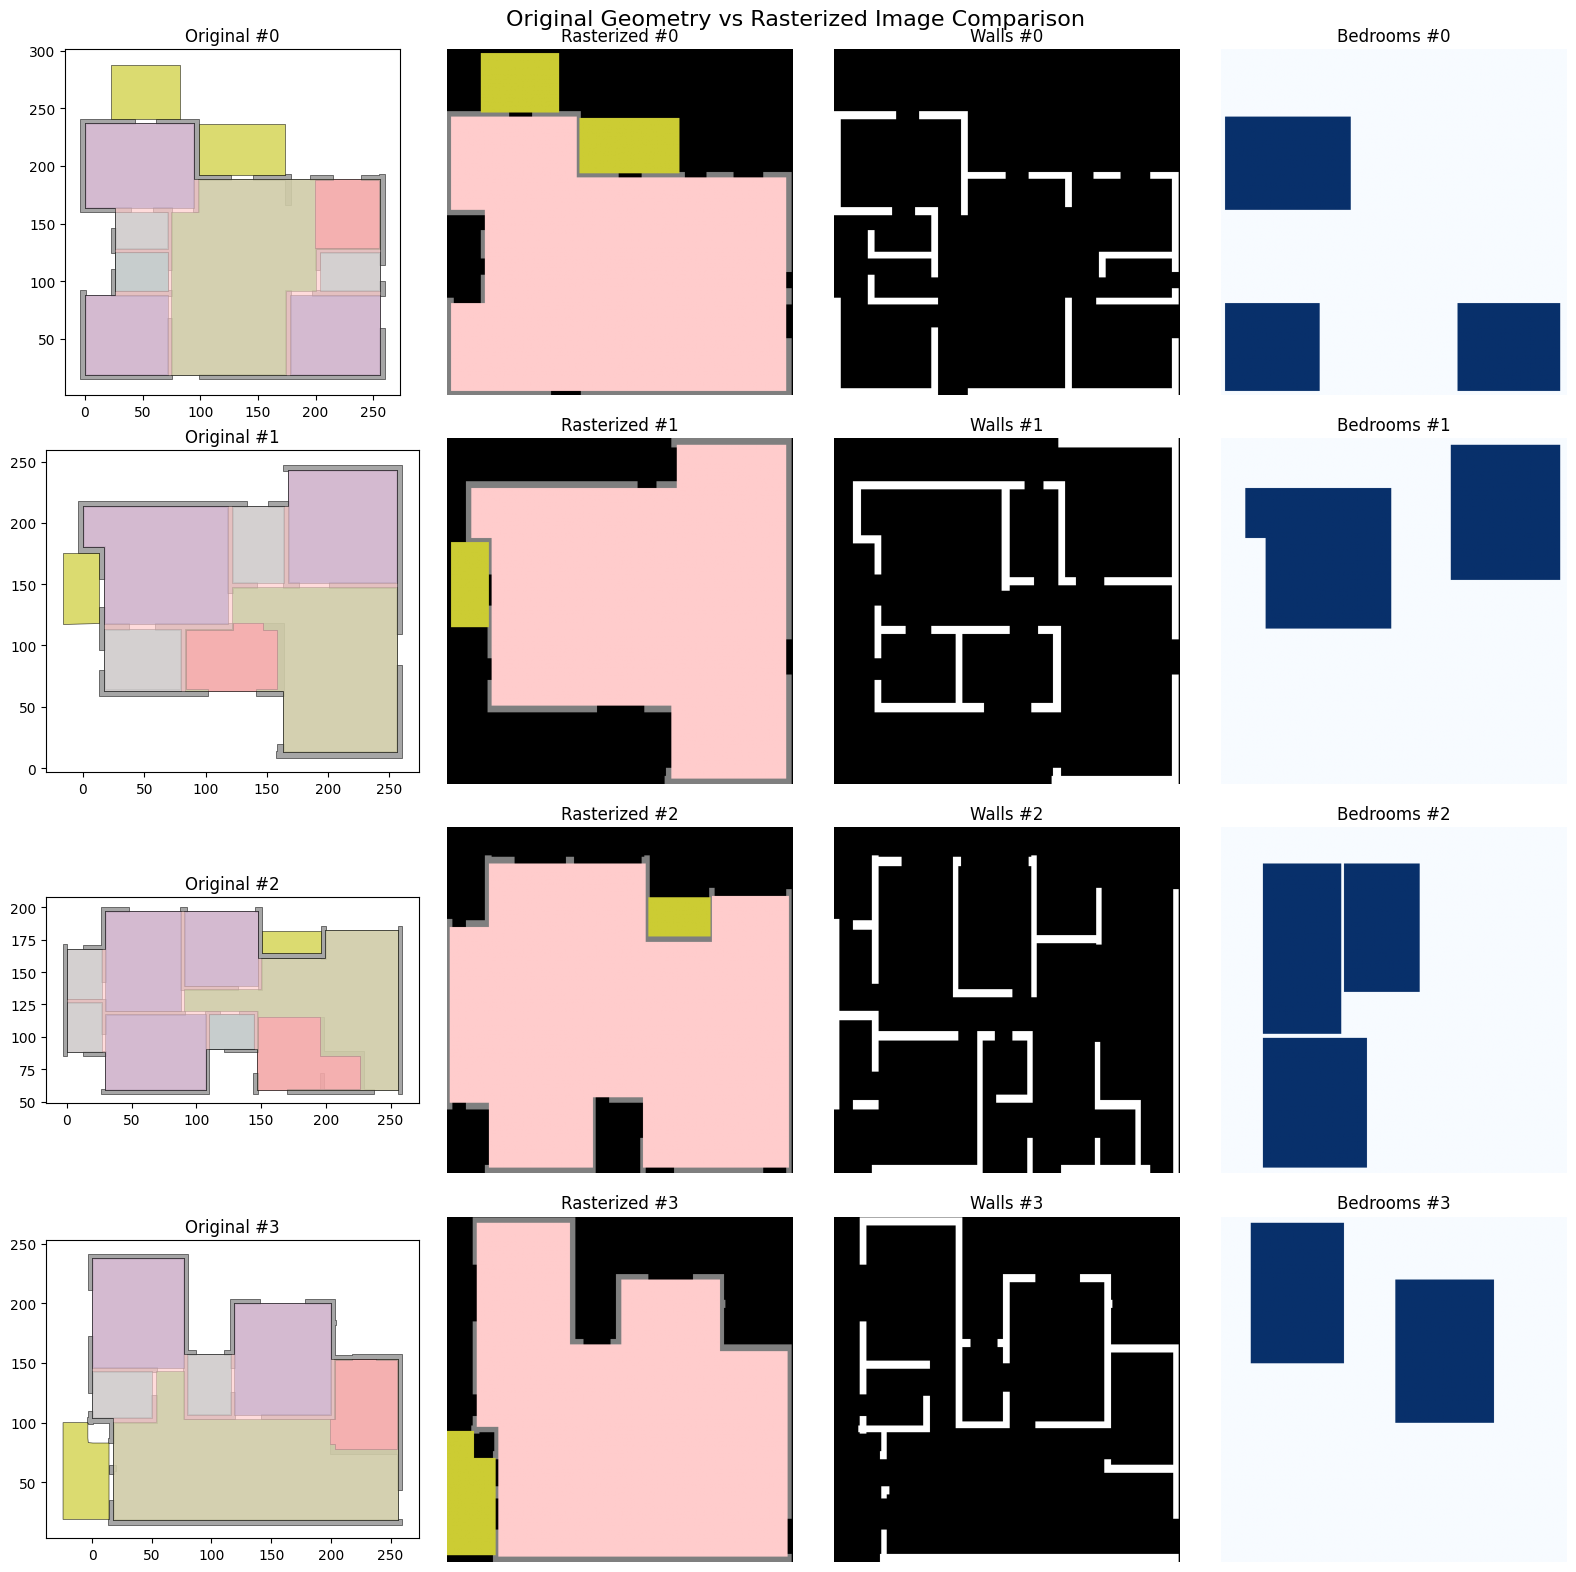

In [13]:
print("Loading original ResPlan data for validation...")
with open(RESPLAN_PKL, 'rb') as f:
    resplan_data = pickle.load(f)

# Load processed metadata
metadata = np.load(os.path.join(OUTPUT_PATH, 'metadata.npy'), allow_pickle=True).item()
norm_constants = np.load(os.path.join(OUTPUT_PATH, 'norm_constants.npy'), allow_pickle=True).item()

print(f"Original dataset: {len(resplan_data)} units")
print(f"Processed dataset: {metadata['total_processed']} units")

# %% [markdown]
# ## 1. Visual Comparison: Original Geometry vs Rasterized Image

# %%
from shapely.geometry import Polygon, MultiPolygon
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection

def plot_original_geometry(unit, ax, title="Original"):
    """Plot original Shapely geometries."""
    colors = {
        'wall': '#808080',
        'bedroom': '#3366CC',
        'bathroom': '#33CCCC',
        'living': '#33CC33',
        'kitchen': '#CC3333',
        'balcony': '#CCCC33',
        'storage': '#996633',
        'parking': '#666666',
        'garden': '#1A991A',
        'pool': '#3399FF',
        'stair': '#9933CC',
        'veranda': '#FF9933',
        'inner': '#FFCCCC',
    }
    
    patches = []
    patch_colors = []
    
    for room_type in ROOM_TYPES:
        if room_type not in unit or unit[room_type] is None:
            continue
        
        geom = unit[room_type]
        if hasattr(geom, 'geoms'):
            polygons = list(geom.geoms)
        else:
            polygons = [geom]
        
        for poly in polygons:
            if poly.is_empty:
                continue
            try:
                if hasattr(poly, 'exterior'):
                    patch = mpatches.Polygon(
                        list(poly.exterior.coords),
                        closed=True
                    )
                    patches.append(patch)
                    patch_colors.append(colors.get(room_type, '#CCCCCC'))
            except:
                continue
    
    if patches:
        collection = PatchCollection(patches, alpha=0.7)
        collection.set_facecolors(patch_colors)
        collection.set_edgecolors('black')
        collection.set_linewidths(0.5)
        ax.add_collection(collection)
        ax.autoscale()
    
    ax.set_aspect('equal')
    ax.set_title(title)


def plot_rasterized_image(image, ax, title="Rasterized"):
    """Plot rasterized semantic mask."""
    colors = {
        'wall': [0.5, 0.5, 0.5],
        'bedroom': [0.2, 0.4, 0.8],
        'bathroom': [0.2, 0.8, 0.8],
        'living': [0.2, 0.8, 0.2],
        'kitchen': [0.8, 0.2, 0.2],
        'balcony': [0.8, 0.8, 0.2],
        'storage': [0.6, 0.4, 0.2],
        'parking': [0.4, 0.4, 0.4],
        'garden': [0.1, 0.6, 0.1],
        'pool': [0.2, 0.6, 1.0],
        'stair': [0.6, 0.2, 0.8],
        'veranda': [1.0, 0.6, 0.2],
        'inner': [1.0, 0.8, 0.8],
    }
    
    rgb = np.zeros((IMG_SIZE, IMG_SIZE, 3))
    
    for i, room_type in enumerate(ROOM_TYPES):
        if room_type in colors:
            mask = image[i] > 127
            for c in range(3):
                rgb[:, :, c] = np.where(mask, colors[room_type][c], rgb[:, :, c])
    
    ax.imshow(np.clip(rgb, 0, 1))
    ax.set_title(title)
    ax.axis('off')


# Load first batch for comparison
batch_data = np.load(os.path.join(OUTPUT_PATH, 'batches', 'batch_0000.npz'))
valid_indices = batch_data['valid_indices']

# Plot comparisons
fig, axes = plt.subplots(4, 4, figsize=(16, 16))

for i in range(4):
    # Get original unit
    orig_idx = valid_indices[i]
    unit = resplan_data[orig_idx]
    
    # Get processed image
    processed_img = batch_data['images'][i]
    
    # Plot original
    plot_original_geometry(unit, axes[i, 0], f"Original #{orig_idx}")
    
    # Plot rasterized
    plot_rasterized_image(processed_img, axes[i, 1], f"Rasterized #{orig_idx}")
    
    # Plot individual channels
    # Walls
    axes[i, 2].imshow(processed_img[ROOM_TYPE_TO_IDX['wall']], cmap='gray')
    axes[i, 2].set_title(f"Walls #{orig_idx}")
    axes[i, 2].axis('off')
    
    # Bedrooms
    axes[i, 3].imshow(processed_img[ROOM_TYPE_TO_IDX['bedroom']], cmap='Blues')
    axes[i, 3].set_title(f"Bedrooms #{orig_idx}")
    axes[i, 3].axis('off')

plt.suptitle('Original Geometry vs Rasterized Image Comparison', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'validation_geometry_comparison.png'), dpi=150)
plt.show()


In [14]:
def count_rooms_original(unit):
    """Count rooms in original ResPlan unit."""
    counts = {}
    for room_type in ROOM_TYPES:
        if room_type in ['wall', 'inner']:
            continue
        if room_type not in unit or unit[room_type] is None:
            counts[room_type] = 0
            continue
        
        geom = unit[room_type]
        if hasattr(geom, 'geoms'):
            counts[room_type] = len([g for g in geom.geoms if not g.is_empty and g.area > 1])
        else:
            counts[room_type] = 1 if not geom.is_empty and geom.area > 1 else 0
    
    return counts


def count_rooms_processed(condition):
    """Extract room counts from processed conditioning vector."""
    counts = {}
    room_count_start = len(norm_constants['unit_types']) + 1
    
    for i, room_type in enumerate(ROOM_TYPES):
        if room_type in ['wall', 'inner']:
            counts[room_type] = 0
            continue
        
        norm_count = condition[room_count_start + i]
        max_count = 10 if room_type in ['bedroom', 'bathroom'] else 5
        counts[room_type] = int(round(norm_count * max_count))
    
    return counts


# Compare room counts
print("Room Count Accuracy Validation")
print("="*60)

conditions = batch_data['conditions']
mismatches = defaultdict(list)
total_checked = 0
total_correct = 0

for i in range(min(100, len(valid_indices))):
    orig_idx = valid_indices[i]
    unit = resplan_data[orig_idx]
    
    orig_counts = count_rooms_original(unit)
    proc_counts = count_rooms_processed(conditions[i])
    
    for room_type in ['bedroom', 'bathroom', 'kitchen', 'living', 'balcony']:
        if room_type in orig_counts and room_type in proc_counts:
            total_checked += 1
            if orig_counts[room_type] == proc_counts[room_type]:
                total_correct += 1
            else:
                mismatches[room_type].append({
                    'idx': orig_idx,
                    'original': orig_counts[room_type],
                    'processed': proc_counts[room_type]
                })

accuracy = total_correct / total_checked * 100 if total_checked > 0 else 0
print(f"\nOverall room count accuracy: {accuracy:.1f}%")
print(f"Checked: {total_checked}, Correct: {total_correct}")

print("\nMismatches by room type:")
for room_type, errors in sorted(mismatches.items(), key=lambda x: -len(x[1])):
    print(f"  {room_type}: {len(errors)} mismatches")
    if len(errors) <= 3:
        for err in errors:
            print(f"    Unit {err['idx']}: orig={err['original']}, proc={err['processed']}")


Room Count Accuracy Validation

Overall room count accuracy: 100.0%
Checked: 80, Correct: 80

Mismatches by room type:


Graph Structure Accuracy Validation

Node count accuracy: 91.1%
Edge recall (orig edges found): 86.6%
Edge precision (proc edges valid): 100.0%


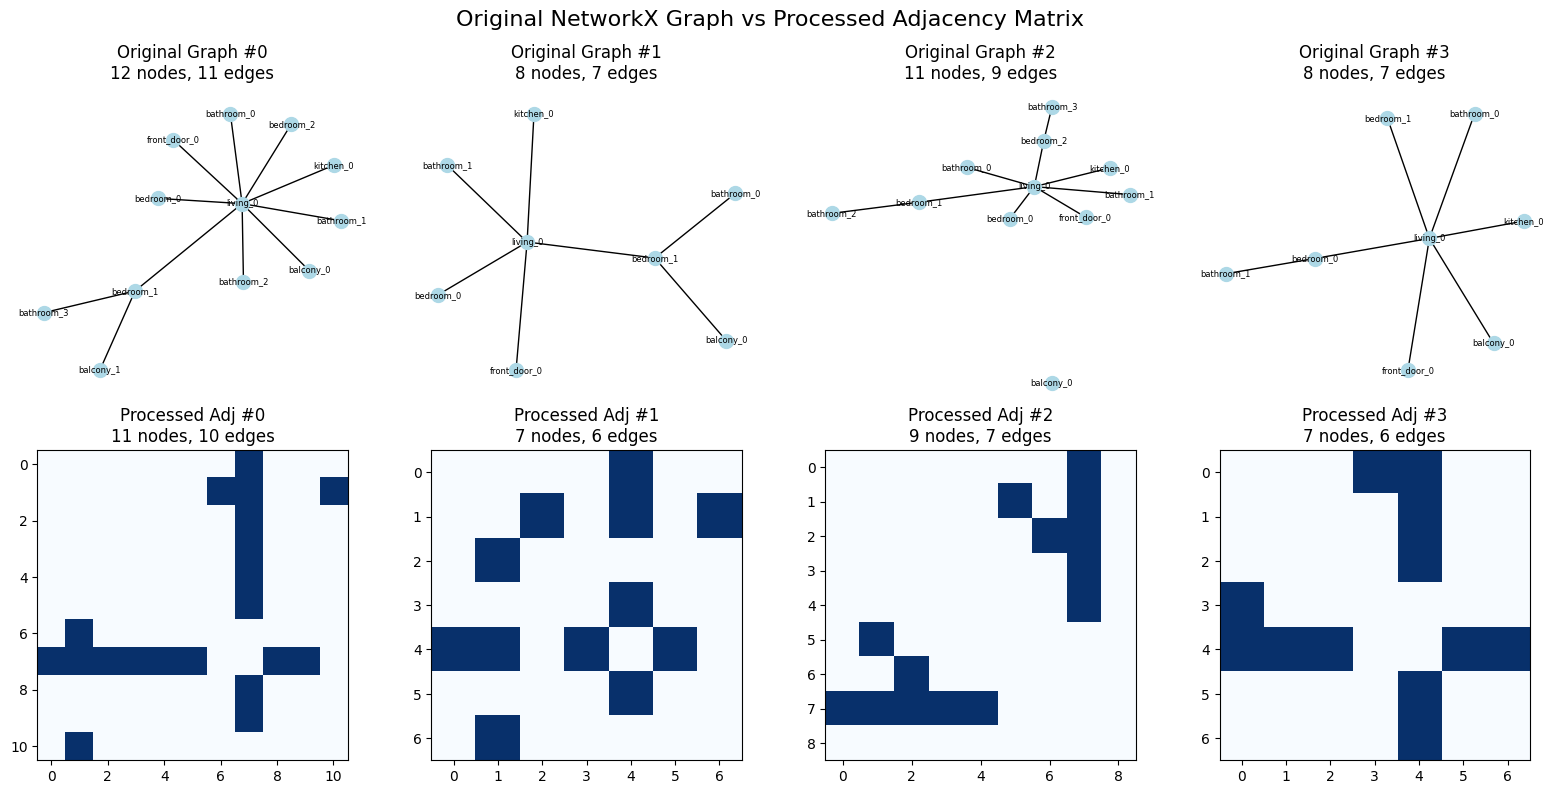

In [15]:
with open(os.path.join(OUTPUT_PATH, 'batches', 'graphs_0000.pkl'), 'rb') as f:
    graph_data = pickle.load(f)

X_list = graph_data['X']
A_list = graph_data['A']

print("Graph Structure Accuracy Validation")
print("="*60)

edge_precision_list = []
edge_recall_list = []
node_count_accuracy = []

for i in range(min(50, len(valid_indices))):
    orig_idx = valid_indices[i]
    unit = resplan_data[orig_idx]
    
    if 'graph' not in unit or unit['graph'] is None:
        continue
    
    orig_graph = unit['graph']
    proc_A = A_list[i]
    
    # Original edge count
    orig_edges = orig_graph.number_of_edges()
    
    # Processed edge count (undirected, so divide by 2)
    proc_edges = int(proc_A.sum() / 2)
    
    # Node count comparison
    orig_nodes = orig_graph.number_of_nodes()
    proc_nodes = proc_A.shape[0]
    
    if orig_nodes > 0:
        node_ratio = min(proc_nodes, orig_nodes) / max(proc_nodes, orig_nodes)
        node_count_accuracy.append(node_ratio)
    
    # Edge density comparison
    if orig_edges > 0:
        edge_recall = min(proc_edges, orig_edges) / orig_edges
        edge_recall_list.append(edge_recall)
    
    if proc_edges > 0:
        edge_precision = min(proc_edges, orig_edges) / proc_edges
        edge_precision_list.append(edge_precision)

print(f"\nNode count accuracy: {np.mean(node_count_accuracy)*100:.1f}%")
print(f"Edge recall (orig edges found): {np.mean(edge_recall_list)*100:.1f}%")
print(f"Edge precision (proc edges valid): {np.mean(edge_precision_list)*100:.1f}%")

# Visualize graph comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    orig_idx = valid_indices[i]
    unit = resplan_data[orig_idx]
    
    # Original graph
    ax = axes[0, i]
    if 'graph' in unit and unit['graph'] is not None:
        G = unit['graph']
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, ax=ax, node_size=100, node_color='lightblue',
                with_labels=True, font_size=6)
        ax.set_title(f"Original Graph #{orig_idx}\n{G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    else:
        ax.text(0.5, 0.5, 'No graph', ha='center', va='center')
        ax.set_title(f"Original #{orig_idx}")
    
    # Processed adjacency matrix
    ax = axes[1, i]
    A = A_list[i]
    # Only show non-zero part
    n = int((A.sum(axis=1) > 0).sum())
    if n > 0:
        ax.imshow(A[:n, :n], cmap='Blues')
        ax.set_title(f"Processed Adj #{orig_idx}\n{n} nodes, {int(A[:n,:n].sum()/2)} edges")
    else:
        ax.imshow(A[:5, :5], cmap='Blues')
        ax.set_title(f"Processed #{orig_idx}")

plt.suptitle('Original NetworkX Graph vs Processed Adjacency Matrix', fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'validation_graph_comparison.png'), dpi=150)
plt.show()


Area and Position Accuracy Validation

Area errors (normalized):
  Mean: 0.0004
  Max: 0.0038
  Std: 0.0011

Position errors (normalized distance):
  Mean: 0.0930
  Max: 0.4587
  Std: 0.1538


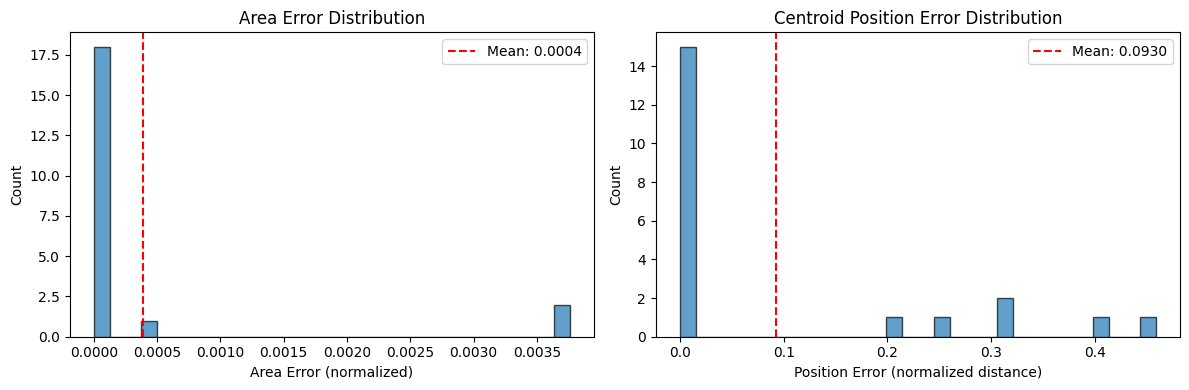

In [16]:
print("Area and Position Accuracy Validation")
print("="*60)

area_errors = []
position_errors = []

for i in range(min(50, len(valid_indices))):
    orig_idx = valid_indices[i]
    unit = resplan_data[orig_idx]
    
    X = X_list[i]
    if len(X) == 0:
        continue
    
    # Get bounds for normalization
    bounds = get_geometry_bounds(unit)
    net_area = float(unit.get('net_area', MEAN_NET_AREA))
    if net_area <= 0:
        net_area = MEAN_NET_AREA
    
    # For each node in processed data
    for j in range(len(X)):
        # Get room type from one-hot
        room_type_idx = np.argmax(X[j, :NUM_ROOM_TYPES])
        room_type = ROOM_TYPES[room_type_idx]
        
        if room_type in ['wall', 'inner']:
            continue
        
        # Get processed values
        proc_area = X[j, NUM_ROOM_TYPES]  # Normalized area
        proc_cx = X[j, NUM_ROOM_TYPES + 1]  # Normalized centroid x
        proc_cy = X[j, NUM_ROOM_TYPES + 2]  # Normalized centroid y
        
        # Get original geometry
        if room_type not in unit or unit[room_type] is None:
            continue
        
        geom = unit[room_type]
        if hasattr(geom, 'geoms'):
            polygons = list(geom.geoms)
        else:
            polygons = [geom]
        
        # Find matching polygon (by area similarity)
        for poly in polygons:
            if poly.is_empty:
                continue
            
            orig_area = poly.area / net_area
            orig_cx, orig_cy = normalize_coordinates(
                poly.centroid.x, poly.centroid.y, bounds
            )
            
            # Check if this is a match (similar area)
            if abs(orig_area - proc_area) < 0.1:
                area_errors.append(abs(orig_area - proc_area))
                pos_error = np.sqrt((orig_cx - proc_cx)**2 + (orig_cy - proc_cy)**2)
                position_errors.append(pos_error)
                break

print(f"\nArea errors (normalized):")
print(f"  Mean: {np.mean(area_errors):.4f}")
print(f"  Max: {np.max(area_errors):.4f}")
print(f"  Std: {np.std(area_errors):.4f}")

print(f"\nPosition errors (normalized distance):")
print(f"  Mean: {np.mean(position_errors):.4f}")
print(f"  Max: {np.max(position_errors):.4f}")
print(f"  Std: {np.std(position_errors):.4f}")

# Plot error distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(area_errors, bins=30, alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Area Error (normalized)')
axes[0].set_ylabel('Count')
axes[0].set_title('Area Error Distribution')
axes[0].axvline(np.mean(area_errors), color='r', linestyle='--', label=f'Mean: {np.mean(area_errors):.4f}')
axes[0].legend()

axes[1].hist(position_errors, bins=30, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Position Error (normalized distance)')
axes[1].set_ylabel('Count')
axes[1].set_title('Centroid Position Error Distribution')
axes[1].axvline(np.mean(position_errors), color='r', linestyle='--', label=f'Mean: {np.mean(position_errors):.4f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'validation_area_position_errors.png'), dpi=150)
plt.show()

In [17]:
print("Pixel Coverage Accuracy Validation")
print("="*60)

coverage_ratios = []

for i in range(min(50, len(valid_indices))):
    orig_idx = valid_indices[i]
    unit = resplan_data[orig_idx]
    
    # Get processed image
    processed_img = batch_data['images'][i]
    
    # Calculate total coverage in original
    total_orig_area = 0
    for room_type in ROOM_TYPES:
        if room_type not in unit or unit[room_type] is None:
            continue
        geom = unit[room_type]
        if hasattr(geom, 'geoms'):
            total_orig_area += sum(g.area for g in geom.geoms if not g.is_empty)
        elif not geom.is_empty:
            total_orig_area += geom.area
    
    # Calculate total coverage in processed (non-zero pixels)
    total_proc_pixels = (processed_img > 0).sum()
    total_pixels = IMG_SIZE * IMG_SIZE * NUM_ROOM_TYPES
    
    # Ratio of filled pixels
    if total_orig_area > 0:
        # Rough comparison (not exact due to different units)
        coverage_ratios.append(total_proc_pixels / total_pixels)

print(f"\nAverage pixel coverage: {np.mean(coverage_ratios)*100:.1f}%")
print(f"Min coverage: {np.min(coverage_ratios)*100:.1f}%")
print(f"Max coverage: {np.max(coverage_ratios)*100:.1f}%")

# %% [markdown]
# ## 6. Summary Report

# %%
print("\n" + "="*60)
print("VALIDATION SUMMARY REPORT")
print("="*60)

print("\n📊 ACCURACY METRICS\n")

print(f"Room Count Accuracy: {accuracy:.1f}%")
print(f"Node Count Accuracy: {np.mean(node_count_accuracy)*100:.1f}%")
print(f"Edge Recall: {np.mean(edge_recall_list)*100:.1f}%")
print(f"Edge Precision: {np.mean(edge_precision_list)*100:.1f}%")
print(f"Mean Area Error: {np.mean(area_errors):.4f}")
print(f"Mean Position Error: {np.mean(position_errors):.4f}")

print("\n📋 QUALITY ASSESSMENT\n")

if accuracy > 90:
    print("✓ Room counts: Excellent")
elif accuracy > 75:
    print("○ Room counts: Good")
else:
    print("✗ Room counts: Needs review")

if np.mean(edge_recall_list) > 0.7:
    print("✓ Graph edges: Good preservation")
elif np.mean(edge_recall_list) > 0.5:
    print("○ Graph edges: Moderate (geometric fallback may be used)")
else:
    print("✗ Graph edges: Low (check NetworkX node naming)")

if np.mean(area_errors) < 0.05:
    print("✓ Areas: Highly accurate")
elif np.mean(area_errors) < 0.1:
    print("○ Areas: Acceptable")
else:
    print("✗ Areas: High error")

if np.mean(position_errors) < 0.1:
    print("✓ Positions: Highly accurate")
elif np.mean(position_errors) < 0.2:
    print("○ Positions: Acceptable")
else:
    print("✗ Positions: High error")

print("\n📁 VALIDATION FILES SAVED\n")
print("  - validation_geometry_comparison.png")
print("  - validation_graph_comparison.png")
print("  - validation_area_position_errors.png")

print("\n" + "="*60)
print("VALIDATION COMPLETE")
print("="*60)

# Clean up
del resplan_data
gc.collect()


Pixel Coverage Accuracy Validation

Average pixel coverage: 11.3%
Min coverage: 9.5%
Max coverage: 13.0%

VALIDATION SUMMARY REPORT

📊 ACCURACY METRICS

Room Count Accuracy: 100.0%
Node Count Accuracy: 91.1%
Edge Recall: 86.6%
Edge Precision: 100.0%
Mean Area Error: 0.0004
Mean Position Error: 0.0930

📋 QUALITY ASSESSMENT

✓ Room counts: Excellent
✓ Graph edges: Good preservation
✓ Areas: Highly accurate
✓ Positions: Highly accurate

📁 VALIDATION FILES SAVED

  - validation_geometry_comparison.png
  - validation_graph_comparison.png
  - validation_area_position_errors.png

VALIDATION COMPLETE


57395